In [412]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score
from sklearn.feature_extraction import DictVectorizer

In [413]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2026-04-22 17:16:00--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.4’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.06s   

2026-04-22 17:16:00 (1.30 MB/s) - ‘course_lead_scoring.csv.4’ saved [80876/80876]



In [414]:
df = pd.read_csv("course_lead_scoring.csv")
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [415]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [416]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   object 
 1   industry                  1328 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   object 
 5   location                  1399 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


## Data preparation
### Check if the missing values are presented in the features.
- If there are missing values:
- For categorical features, replace them with 'NA'
- For numerical features, replace with with 0.0

In [417]:
objects = ['lead_source', 'industry', 'employment_status', 'location']
numerics = ['annual_income']

In [418]:
df[objects] = df[objects].fillna("NAN")
df[numerics] = df[numerics].fillna(0.0)
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

----------------------------------------------------------------------------------------------------------------------------------------

# Question 1
## What is the most frequent observation (mode) for the column industry?

In [419]:
df['industry'].value_counts()

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NAN              134
Name: count, dtype: int64

---

## Question 2
### Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation          coefficient between every pair of features.

### What are the two features that have the biggest correlation?



In [420]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1462 non-null   object 
 1   industry                  1462 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1462 non-null   float64
 4   employment_status         1462 non-null   object 
 5   location                  1462 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


In [421]:
numerics = [i for i in df.columns if df[i].dtype in (np.int64, np.float64)]
numerics

['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score',
 'converted']

<Axes: >

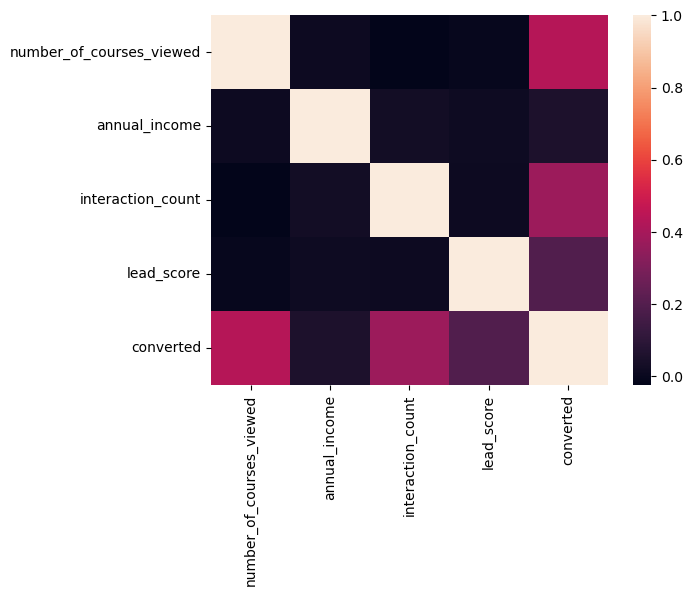

In [422]:
corr = df[numerics].corr()
sns.heatmap(corr)

- interaction_count and lead_score
- number_of_courses_viewed and lead_score 
- number_of_courses_viewed and interaction_count
- annual_income and interaction_count


In [423]:
corr.columns

Index(['number_of_courses_viewed', 'annual_income', 'interaction_count',
       'lead_score', 'converted'],
      dtype='object')

In [424]:
print(corr.loc['interaction_count', 'lead_score'])
print(corr.loc['number_of_courses_viewed', 'lead_score'])
print(corr.loc['number_of_courses_viewed', 'interaction_count'])
print(corr.loc['annual_income', 'interaction_count'])

0.009888182496913131
-0.004878998354681276
-0.023565222882888037
0.02703647240481443


---


## Split the data
- Split your data in train/val/test sets with 60%/20%/20% distribution.
- Use Scikit-Learn for that (the train_test_split function) and set the seed to 42.
- Make sure that the target value converted is not in your dataframe.

In [425]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

y_train, y_val, y_test = df_train['converted'], df_val['converted'], df_test['converted']
df_train, df_val, df_test = df_train.drop('converted', axis=1), df_val.drop('converted', axis=1), df_test.drop('converted', axis=1)

len(df_train)/ len(df), len(df_val)/ len(df), len(df_test) / len(df)

(0.5991792065663475, 0.20041039671682626, 0.20041039671682626)

In [426]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

---


## Question 3
- Calculate the mutual information score between converted and other categorical variables in the dataset. Use the training set only.
- Round the scores to 2 decimals using round(score, 2).

In [427]:
objects = [i for i in df.columns if df[i].dtype not in (np.int64, np.float64)]
df_train_objects = df_train[objects]
for obj in df_train_objects.columns:
    print(f'{obj} has a relationship with converted {round(mutual_info_score(y_train, df_train_objects[obj]), 2)} \n')

lead_source has a relationship with converted 0.04 

industry has a relationship with converted 0.01 

employment_status has a relationship with converted 0.01 

location has a relationship with converted 0.0 



---

## Question 4
- Now let's train a logistic regression.
- Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
- Fit the model on the training dataset.
- To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
- model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
- Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

In [428]:
df_train_numerics = [i for i in df.columns if df[i].dtype  in (np.int64, np.float64)]
df[df_train_numerics].columns

Index(['number_of_courses_viewed', 'annual_income', 'interaction_count',
       'lead_score', 'converted'],
      dtype='object')

In [429]:
df_train_objects.columns

Index(['lead_source', 'industry', 'employment_status', 'location'], dtype='object')

In [430]:
for col in df_train_objects:
    print(f'{col} :{df_train_objects[col].unique()} \n')

lead_source :['paid_ads' 'organic_search' 'NAN' 'social_media' 'events' 'referral'] 

industry :['retail' 'manufacturing' 'technology' 'finance' 'NAN' 'education'
 'healthcare' 'other'] 

employment_status :['student' 'employed' 'unemployed' 'NAN' 'self_employed'] 

location :['middle_east' 'north_america' 'europe' 'australia' 'south_america'
 'africa' 'asia' 'NAN'] 



In [431]:
train_dicts = df_train.to_dict(orient='records')

In [432]:
dv = DictVectorizer(sparse=False)

In [433]:
X_train = dv.fit_transform(train_dicts)

In [434]:
val_dicts = df_val.to_dict(orient='records')

In [435]:
X_val = dv.transform(val_dicts)

### Vectorized Implementation (Matrix Form) 
To compute the predictions for $m$ examples with $n$ features simultaneously, we define our matrices as follows:$X$ (Feature Matrix): Shape $(m, n)$$w$ (Weight Vector): Shape $(n, 1)$$y$ (Label Vector): Shape $(m, 1)$$b$ (Bias): A scalar (broadcasted during addition)1. Linear Prediction (Logits)Instead of calculating $z$ for each row, we compute the entire vector $Z$ in one operation:$$Z = Xw + b$$Where $Z$ is an $(m, 1)$ vector.2. Activation (Sigmoid)Apply the sigmoid function element-wise to the vector $Z$:$$A = \sigma(Z) = \frac{1}{1 + e^{-Z}}$$Here, $A$ (also called $\hat{Y}$) is the vector of predicted probabilities for all $m$ examples.3. Vectorized Cost Function (Log Loss)Using the dot product, the cost function $J$ can be written without a summation sign:$$J(w, b) = -\frac{1}{m} \left( y^T \log(A) + (1 - y)^T \log(1 - A) \right)$$4. Vectorized Gradient DescentThe gradients (derivatives) used to update $w$ and $b$ are also calculated for all samples at once:Gradient for weights ($dw$):$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (A - y)$$(Resulting shape is $(n, 1)$, matching the weights)Gradient for bias ($db$):$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (a^{(i)} - y^{(i)})$$

In [444]:
model = LogisticRegression( C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

/home/amirarsalan/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [445]:
y_pred = model.predict(X_val)

In [446]:
acc = round(accuracy_score(y_val, y_pred), 2)
acc

0.86

## Question 5
### Let's find the least useful feature using the feature elimination technique.
- Train a model using the same features and parameters as in Q4 (without rounding).
- Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
- For each feature, calculate the difference between the original accuracy and the accuracy without the feature.
### Which of following feature has the smallest difference?
- 'industry'
- 'employment_status'
- 'lead_score'

In [439]:
features = ['industry', 'employment_status', 'lead_score']
features

['industry', 'employment_status', 'lead_score']

In [440]:
small_diff = {}

for i in features:
    df_train_c = df_train.drop(i, axis=1)
    df_val_c = df_val.drop(i, axis=1)
    
    train_dicts_c = df_train_c.to_dict(orient='records')
    val_dicts_c = df_val_c.to_dict(orient='records')
    
    dv_c = DictVectorizer(sparse=False)
    dv_c.fit(train_dicts_c)
    
    X_train_c = dv_c.transform(train_dicts_c)
    X_val_c = dv_c.transform(val_dicts_c)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train_c, y_train)
    y_pred_c = model.predict(X_val_c)
    
    small_diff[i] = abs(acc - accuracy_score(y_val, y_pred_c))
    
small_diff

{'industry': 0.0003412969283276279,
 'employment_status': 0.003754266211604018,
 'lead_score': 0.006484641638225264}

---


## Question 6
#### Now let's train a regularized logistic regression.   
#### Let's try the following values of the parameter C: [0.01, 0.1, 1, 10, 100].   
#### Train models using all the features as in Q4.   
#### Calculate the accuracy on the validation dataset and round it to 3 decimal digits.  
#### Which of these C leads to the best accuracy on the validation set?   

- 0.01
- 0.1
- 1
- 10
- 100

In [448]:
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(
        max_iter=1000,
        C=C,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    
    score = accuracy_score(y_val, y_pred)
    scores[C] = round(score, 3)
    print(f'C = {C}:\t Accuracy = {score}')

C = 0.01:	 Accuracy = 0.8122866894197952
C = 0.1:	 Accuracy = 0.8430034129692833
C = 1:	 Accuracy = 0.856655290102389
C = 10:	 Accuracy = 0.856655290102389
C = 100:	 Accuracy = 0.8532423208191127


/home/amirarsalan/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/amirarsalan/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.or